In [1]:
import pandas as pd
import numpy as np

In [ ]:
# Loaading our data
date_files = {
    'sessions': ('session_time',),
    'riders': ('signup_date',),
    'trips': ('pickup_time', 'dropoff_time'),
    'promotions': ('start_date', 'end_date'),
    'drivers': ('signup_date', 'last_active')
}

dfs={}
for table, date_cols in date_files.items():
    dfs[table] = pd.read_csv(f'../data/{table}.csv', parse_dates=list(date_cols))

Before moing ahead, we convert all datetime columns to datetime datatype

In [3]:


# Assuming our dataframes are stored in a dictionary named 'dfs'
# e.g., dfs = {'riders': riders_df, 'sessions': sessions_df, ...}

print("--- Starting Datetime Data Type Conversions ---")

# 1. Cleaning 'riders' table
# Note: info() showed it parsed successfully, but we enforce UTC normalization for alignment
dfs['riders']['signup_date'] = pd.to_datetime(dfs['riders']['signup_date'], utc=True)
print("✔ 'riders': signup_date converted.")

# 2. Cleaning 'sessions' table
dfs['sessions']['session_time'] = pd.to_datetime(dfs['sessions']['session_time'], utc=True)
print("✔ 'sessions': session_time converted.")

# 3. Cleaning 'trips' table (CRITICAL: Handles the complex timezone offsets)
dfs['trips']['pickup_time'] = pd.to_datetime(dfs['trips']['pickup_time'], utc=True)
dfs['trips']['dropoff_time'] = pd.to_datetime(dfs['trips']['dropoff_time'], utc=True)
print("✔ 'trips': pickup_time and dropoff_time converted.")

# 4. Cleaning 'promotions' table
dfs['promotions']['start_date'] = pd.to_datetime(dfs['promotions']['start_date'], utc=True)
dfs['promotions']['end_date'] = pd.to_datetime(dfs['promotions']['end_date'], utc=True)
print("✔ 'promotions': start_date and end_date converted.")

# 5. Cleaning 'drivers' table
dfs['drivers']['signup_date'] = pd.to_datetime(dfs['drivers']['signup_date'], utc=True)
dfs['drivers']['last_active'] = pd.to_datetime(dfs['drivers']['last_active'], utc=True)
print("✔ 'drivers': signup_date and last_active converted.")

print("\n--- All conversions complete! Verification: ---")
print(f"Trips pickup_time dtype: {dfs['trips']['pickup_time'].dtype}")
print(f"Sessions session_time dtype: {dfs['sessions']['session_time'].dtype}")

--- Starting Datetime Data Type Conversions ---
✔ 'riders': signup_date converted.
✔ 'sessions': session_time converted.
✔ 'trips': pickup_time and dropoff_time converted.
✔ 'promotions': start_date and end_date converted.
✔ 'drivers': signup_date and last_active converted.

--- All conversions complete! Verification: ---
Trips pickup_time dtype: datetime64[us, UTC]
Sessions session_time dtype: datetime64[us, UTC]


In [13]:
dfs['promotions'].info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   promo_id         20 non-null     str                
 1   promo_name       20 non-null     str                
 2   promo_type       20 non-null     str                
 3   promo_value      20 non-null     float64            
 4   start_date       20 non-null     datetime64[us, UTC]
 5   end_date         20 non-null     datetime64[us, UTC]
 6   target_segment   20 non-null     str                
 7   city_scope       20 non-null     str                
 8   ab_test_groups   20 non-null     str                
 9   test_allocation  20 non-null     str                
 10  success_metric   20 non-null     str                
dtypes: datetime64[us, UTC](2), float64(1), str(8)
memory usage: 1.8 KB


EDA FOR TABLE: riders

--- Categorical Feature Exploration ---

Feature: 'city' | Distinct Categories (Cardinality): 3
city
Cairo      3374
Nairobi    3330
Lagos      3296
Name: count, dtype: int64

Feature: 'loyalty_status' | Distinct Categories (Cardinality): 4
loyalty_status
Bronze      6057
Silver      2425
Gold        1050
Platinum     468
Name: count, dtype: int64

Total rows in riders: 10000
Unique User IDs: 10000


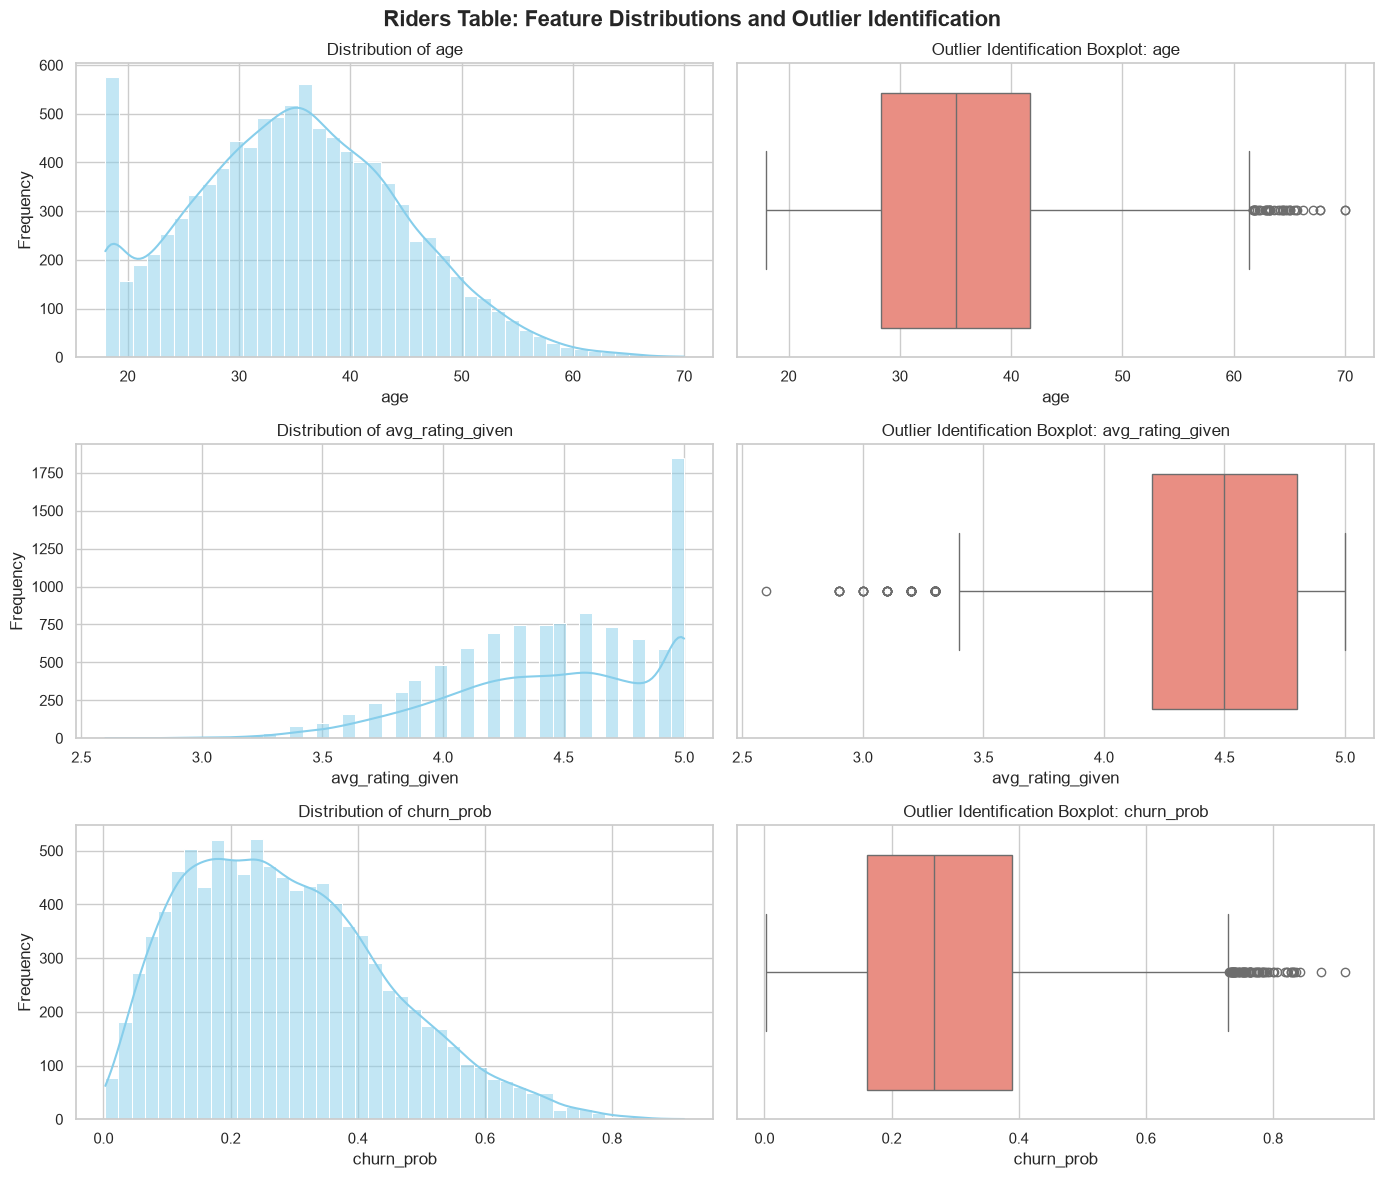


--- Numerical Summary Statistics (Check Min/Max for anomalies) ---
                age  avg_rating_given    churn_prob
count  10000.000000      10000.000000  10000.000000
mean      35.154221          4.461510      0.286168
std        9.545528          0.429162      0.159029
min       18.000000          2.600000      0.002934
25%       28.317568          4.200000      0.161691
50%       35.037671          4.500000      0.266712
75%       41.691186          4.800000      0.388812
max       70.000000          5.000000      0.913302


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure visualization styles are crisp
sns.set_theme(style="whitegrid")

print("==================================================")
print("EDA FOR TABLE: riders")
print("==================================================")

# --- 1. Category and Cardinality Checks ---
print("\n--- Categorical Feature Exploration ---")
categorical_cols_riders = ['city', 'loyalty_status']

for col in categorical_cols_riders:
    cardinality = dfs['riders'][col].nunique()
    value_counts = dfs['riders'][col].value_counts()
    print(f"\nFeature: '{col}' | Distinct Categories (Cardinality): {cardinality}")
    print(value_counts)

# Check unique constraints on the Primary Key
print(f"\nTotal rows in riders: {len(dfs['riders'])}")
print(f"Unique User IDs: {dfs['riders']['user_id'].nunique()}")

# --- 2. Numerical Distributions & 3. Outlier Detection ---
numerical_cols_riders = ['age', 'avg_rating_given', 'churn_prob']

# Setup a clean plotting canvas for distributions and outliers
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))
fig.suptitle('Riders Table: Feature Distributions and Outlier Identification', fontsize=16, fontweight='bold')

for i, col in enumerate(numerical_cols_riders):
    # Column Left: Distribution Plot (Histogram + Kernel Density Estimate)
    sns.histplot(data=dfs['riders'], x=col, kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Distribution of {col}')
    axes[i, 0].set_ylabel('Frequency')
    
    # Column Right: Boxplot to visually isolate outliers beyond the Interquartile Range (IQR)
    sns.boxplot(data=dfs['riders'], x=col, ax=axes[i, 1], color='salmon')
    axes[i, 1].set_title(f'Outlier Identification Boxplot: {col}')

plt.tight_layout()
plt.show()

# Print statistical summaries for outlier reference points
print("\n--- Numerical Summary Statistics (Check Min/Max for anomalies) ---")
print(dfs['riders'][numerical_cols_riders].describe())

EDA FOR TABLE: sessions

--- Categorical & Flag Feature Exploration ---
Total Session Records: 50000
Unique Sessions (Primary Key): 50000
Unique Riders in Session Log: 9929

Feature: 'converted' | Cardinality: 2
converted
0    42186
1     7814
Name: count, dtype: int64

Feature: 'city' | Cardinality: 3
city
Cairo      16967
Nairobi    16598
Lagos      16435
Name: count, dtype: int64

Feature: 'loyalty_status' | Cardinality: 4
loyalty_status
Bronze      30298
Silver      12170
Gold         5197
Platinum     2335
Name: count, dtype: int64


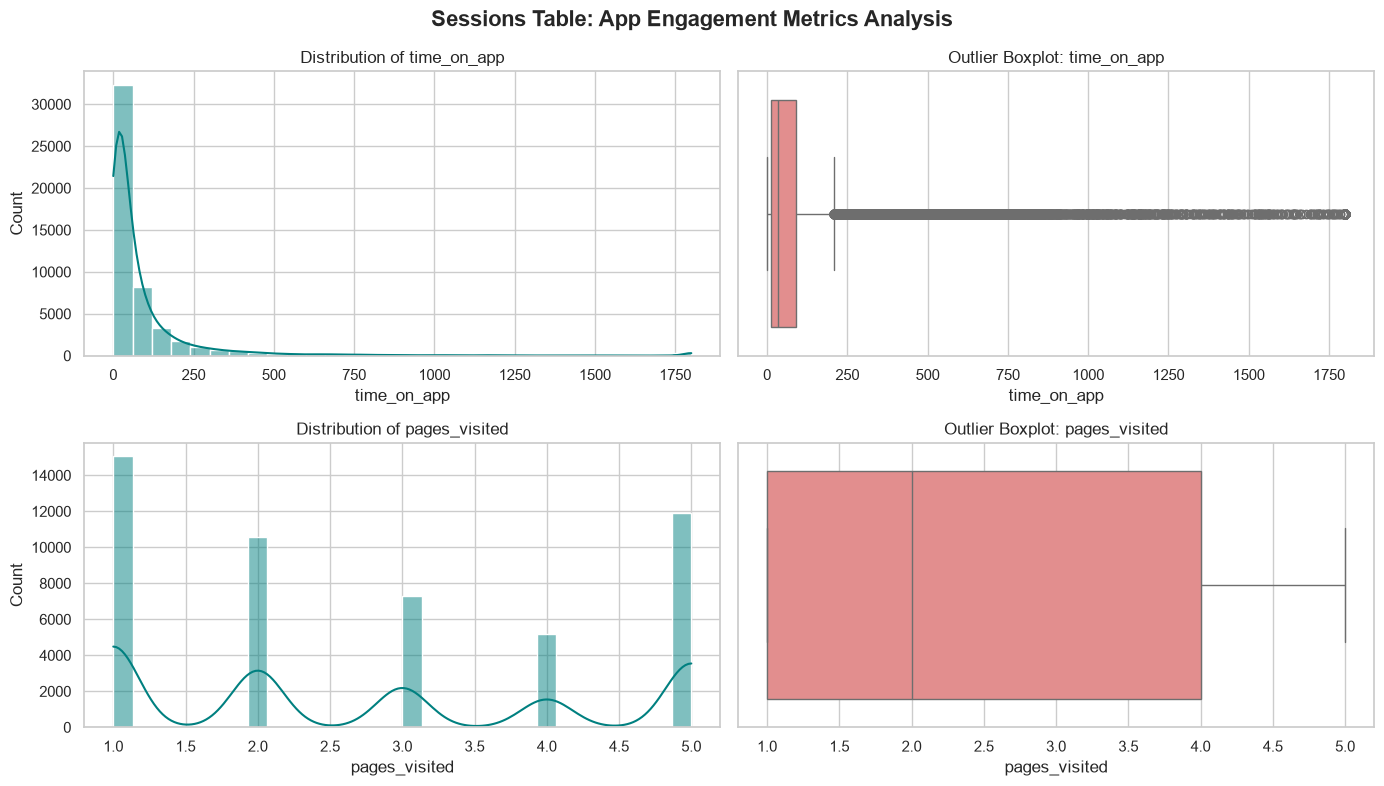


--- Session Metric Summaries ---
        time_on_app  pages_visited
count  50000.000000   50000.000000
mean      97.940880       2.766360
std      211.675749       1.554137
min        0.000000       1.000000
25%       12.000000       1.000000
50%       35.000000       2.000000
75%       90.000000       4.000000
max     1800.000000       5.000000


In [15]:
print("==================================================")
print("EDA FOR TABLE: sessions")
print("==================================================")

# --- 1. Category and Cardinality Checks ---
print("\n--- Categorical & Flag Feature Exploration ---")
# checking unique sessions vs total records
print(f"Total Session Records: {len(dfs['sessions'])}")
print(f"Unique Sessions (Primary Key): {dfs['sessions']['session_id'].nunique()}")
print(f"Unique Riders in Session Log: {dfs['sessions']['rider_id'].nunique()}")

# Checking conversion rates and city breakdowns inside app sessions
for col in ['converted', 'city', 'loyalty_status']:
    print(f"\nFeature: '{col}' | Cardinality: {dfs['sessions'][col].nunique()}")
    print(dfs['sessions'][col].value_counts(dropna=False))

# --- 2. Numerical Distributions & 3. Outlier Detection ---
numerical_cols_sessions = ['time_on_app', 'pages_visited']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 8))
fig.suptitle('Sessions Table: App Engagement Metrics Analysis', fontsize=16, fontweight='bold')

for i, col in enumerate(numerical_cols_sessions):
    # Left: Distribution
    sns.histplot(data=dfs['sessions'], x=col, kde=True, ax=axes[i, 0], color='teal', bins=30)
    axes[i, 0].set_title(f'Distribution of {col}')
    
    # Right: Boxplot to flag extreme app usage behaviors or bot interactions
    sns.boxplot(data=dfs['sessions'], x=col, ax=axes[i, 1], color='lightcoral')
    axes[i, 1].set_title(f'Outlier Boxplot: {col}')

plt.tight_layout()
plt.show()

print("\n--- Session Metric Summaries ---")
print(dfs['sessions'][numerical_cols_sessions].describe())

EDA FOR TABLE: trips

--- Categorical Feature Exploration ---

Feature: 'payment_type' | Cardinality: 3
payment_type
Card            100326
Mobile Money     79661
Cash             20013
Name: count, dtype: int64

Feature: 'weather' | Cardinality: 4
weather
Sunny     120151
Rainy      39976
Cloudy     29874
Foggy       9999
Name: count, dtype: int64

Feature: 'city' | Cardinality: 3
city
Cairo      67436
Nairobi    66705
Lagos      65859
Name: count, dtype: int64

Feature: 'loyalty_status' | Cardinality: 4
loyalty_status
Bronze      121252
Silver       48332
Gold         21044
Platinum      9372
Name: count, dtype: int64

Total Trips Profiled: 200000
Distinct Users Taking Trips: 10000
Distinct Drivers Executing Trips: 5000


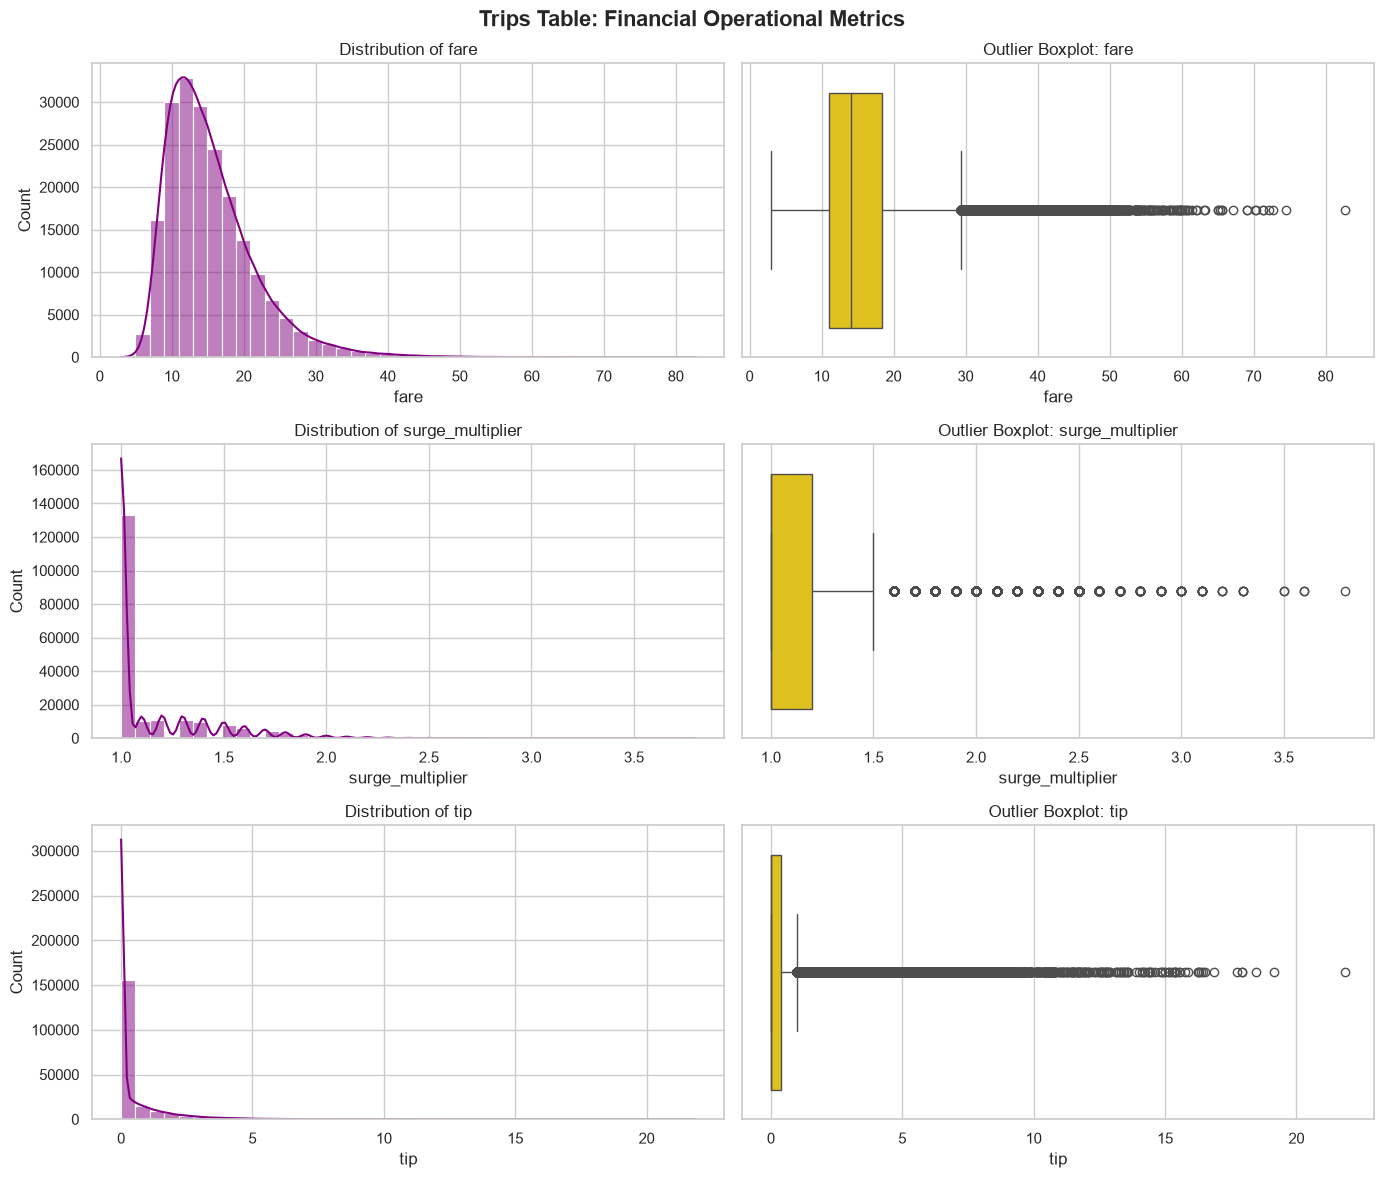


--- Trip Financial Summaries ---
                fare  surge_multiplier            tip
count  200000.000000     200000.000000  200000.000000
mean       15.401285          1.141500       0.469566
std         6.163199          0.255362       1.100545
min         2.970000          1.000000       0.000000
25%        11.000000          1.000000       0.000000
50%        14.130000          1.000000       0.000000
75%        18.350000          1.200000       0.400000
max        82.740000          3.800000      21.860000


In [16]:
print("==================================================")
print("EDA FOR TABLE: trips")
print("==================================================")

# --- 1. Category and Cardinality Checks ---
print("\n--- Categorical Feature Exploration ---")
categorical_cols_trips = ['payment_type', 'weather', 'city', 'loyalty_status']

for col in categorical_cols_trips:
    print(f"\nFeature: '{col}' | Cardinality: {dfs['trips'][col].nunique()}")
    print(dfs['trips'][col].value_counts())

print(f"\nTotal Trips Profiled: {len(dfs['trips'])}")
print(f"Distinct Users Taking Trips: {dfs['trips']['user_id'].nunique()}")
print(f"Distinct Drivers Executing Trips: {dfs['trips']['driver_id'].nunique()}")

# --- 2. Numerical Distributions & 3. Outlier Detection ---
# Selecting core operational financial metrics
numerical_cols_trips = ['fare', 'surge_multiplier', 'tip']

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))
fig.suptitle('Trips Table: Financial Operational Metrics', fontsize=16, fontweight='bold')

for i, col in enumerate(numerical_cols_trips):
    # Left: Distribution (Crucial for visualizing highly skewed features like Tips or Surge)
    sns.histplot(data=dfs['trips'], x=col, kde=True, ax=axes[i, 0], color='purple', bins=40)
    axes[i, 0].set_title(f'Distribution of {col}')
    
    # Right: Boxplot (Highly vital here to identify abnormally massive distance/fare anomalies)
    sns.boxplot(data=dfs['trips'], x=col, ax=axes[i, 1], color='gold')
    axes[i, 1].set_title(f'Outlier Boxplot: {col}')

plt.tight_layout()
plt.show()

print("\n--- Trip Financial Summaries ---")
print(dfs['trips'][numerical_cols_trips].describe())

EDA FOR TABLE: promotions

--- Categorical & Strategic Campaign Exploration ---

Feature: 'promo_name' | Cardinality: 4
promo_name
First Ride Discount    8
Peak Hour Pass         5
Loyalty Bonus          5
Referral Special       2
Name: count, dtype: int64

Feature: 'promo_type' | Cardinality: 4
promo_type
discount        8
surge_waiver    5
points          5
credit          2
Name: count, dtype: int64

Feature: 'target_segment' | Cardinality: 4
target_segment
New       8
All       5
Gold+     5
Active    2
Name: count, dtype: int64

Feature: 'city_scope' | Cardinality: 4
city_scope
Nairobi       6
Lagos         5
All-Cities    5
Cairo         4
Name: count, dtype: int64

Feature: 'success_metric' | Cardinality: 3
success_metric
ROI                10
Usage Frequency     6
Conversion Rate     4
Name: count, dtype: int64

--- Campaign Financial Values Distribution ---
count     20.000000
mean      26.870000
std       43.538115
min        0.300000
25%        0.300000
50%        1.000000
7

C:\Users\gideo\AppData\Local\Temp\ipykernel_7020\2309832081.py:20: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=dfs['promotions'], x='promo_type', y='promo_value', hue='city_scope', ci=None, palette='Set2')


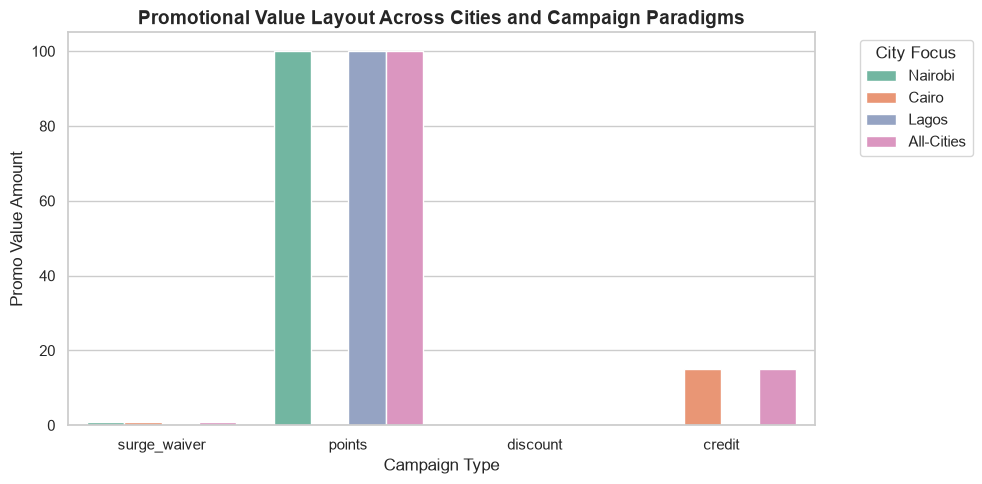

In [17]:
print("==================================================")
print("EDA FOR TABLE: promotions")
print("==================================================")

# --- 1. Category and Cardinality Checks ---
print("\n--- Categorical & Strategic Campaign Exploration ---")
categorical_cols_promo = ['promo_name', 'promo_type', 'target_segment', 'city_scope', 'success_metric']

for col in categorical_cols_promo:
    print(f"\nFeature: '{col}' | Cardinality: {dfs['promotions'][col].nunique()}")
    print(dfs['promotions'][col].value_counts())

# --- 2. Numerical Distributions & 3. Outlier Detection ---
print("\n--- Campaign Financial Values Distribution ---")
print(dfs['promotions']['promo_value'].describe())

# Since promotions contains exactly 20 strategic records, standard continuous boxplots offer low utility.
# Instead, a categorical bar display acts as the clearest asset check.
plt.figure(figsize=(10, 5))
sns.barplot(data=dfs['promotions'], x='promo_type', y='promo_value', hue='city_scope', ci=None, palette='Set2')
plt.title('Promotional Value Layout Across Cities and Campaign Paradigms', fontsize=14, fontweight='bold')
plt.ylabel('Promo Value Amount')
plt.xlabel('Campaign Type')
plt.legend(title='City Focus', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

EDA FOR TABLE: drivers

--- Supply-Side Categorical Exploration ---
Total Registered Drivers: 5000
Unique Driver IDs: 5000

Feature: 'vehicle_type' | Cardinality: 4
vehicle_type
Sedan         2439
SUV           1742
Motorcycle     675
Luxury         144
Name: count, dtype: int64

Feature: 'city' | Cardinality: 3
city
Lagos      1720
Nairobi    1709
Cairo      1571
Name: count, dtype: int64


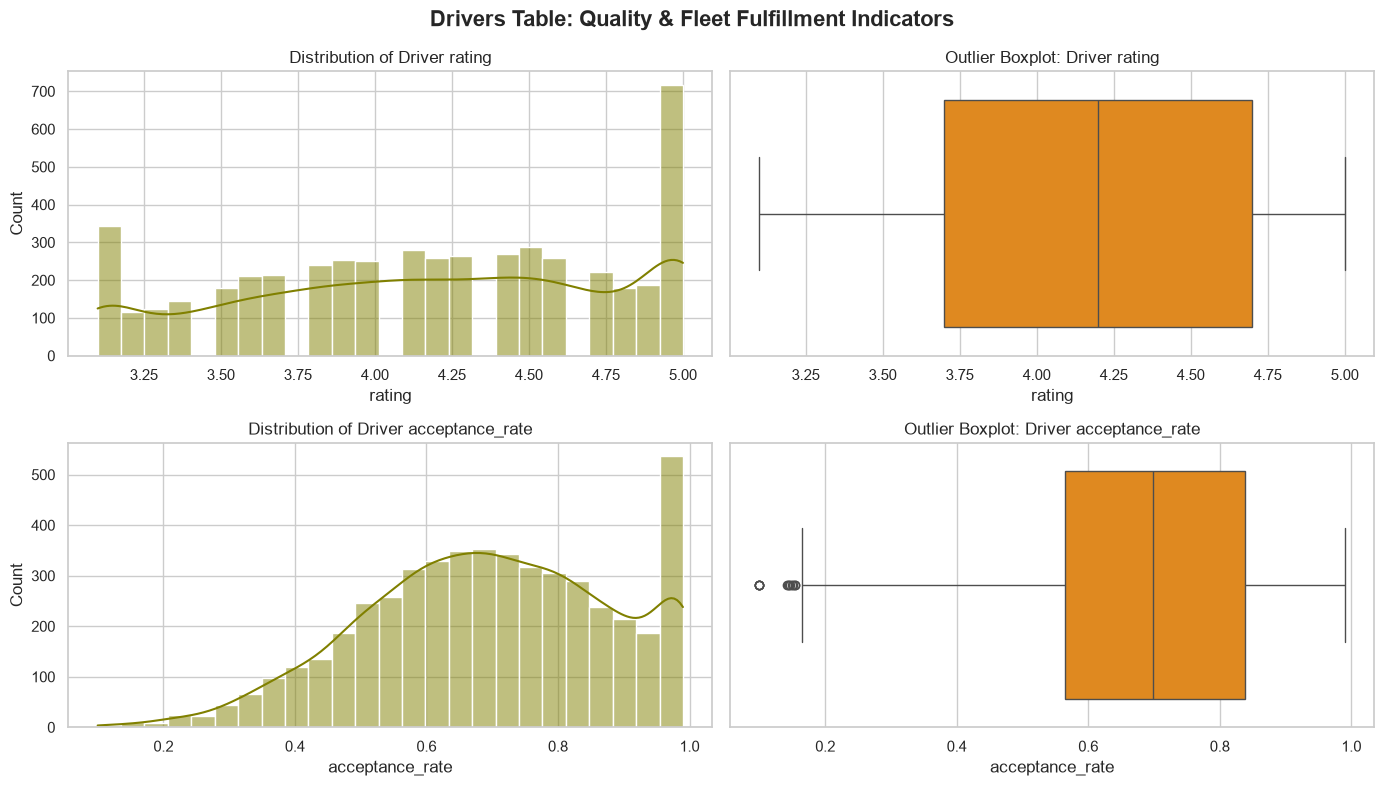


--- Operational Fleet Metrics Summary ---
            rating  acceptance_rate
count  5000.000000      5000.000000
mean      4.172440         0.695318
std       0.594073         0.186216
min       3.100000         0.100000
25%       3.700000         0.565169
50%       4.200000         0.697731
75%       4.700000         0.837700
max       5.000000         0.990000


In [18]:
print("==================================================")
print("EDA FOR TABLE: drivers")
print("==================================================")

# --- 1. Category and Cardinality Checks ---
print("\n--- Supply-Side Categorical Exploration ---")
print(f"Total Registered Drivers: {len(dfs['drivers'])}")
print(f"Unique Driver IDs: {dfs['drivers']['driver_id'].nunique()}")

for col in ['vehicle_type', 'city']:
    print(f"\nFeature: '{col}' | Cardinality: {dfs['drivers'][col].nunique()}")
    print(dfs['drivers'][col].value_counts())

# --- 2. Numerical Distributions & 3. Outlier Detection ---
numerical_cols_drivers = ['rating', 'acceptance_rate']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 8))
fig.suptitle('Drivers Table: Quality & Fleet Fulfillment Indicators', fontsize=16, fontweight='bold')

for i, col in enumerate(numerical_cols_drivers):
    # Left: Distribution Profile
    sns.histplot(data=dfs['drivers'], x=col, kde=True, ax=axes[i, 0], color='olive', bins=25)
    axes[i, 0].set_title(f'Distribution of Driver {col}')
    
    # Right: Boxplot to isolate poor-performing or low-acceptance driver outliers
    sns.boxplot(data=dfs['drivers'], x=col, ax=axes[i, 1], color='darkorange')
    axes[i, 1].set_title(f'Outlier Boxplot: Driver {col}')

plt.tight_layout()
plt.show()

print("\n--- Operational Fleet Metrics Summary ---")
print(dfs['drivers'][numerical_cols_drivers].describe())

### Question 1: How do driver ratings and vehicle types affect rider trip satisfaction and financial spending?

Why it matters: If riders in Lagos or Nairobi consistently receive low-rated drivers or get stuck with vehicle types they don't like (e.g., a motorcycle when they wanted an SUV), their satisfaction drops. This directly hurts their likelihood to reuse RideWise, driving up churn. Understanding this dynamic helps the operations team optimize fleet management and driver quality controls.

ANALYSIS 1: Impact of Driver & Vehicle Metrics on Fares

--- Fleet Segment Performance Summary ---
  vehicle_type  total_trips   avg_fare   avg_tip  avg_driver_rating
0       Luxury         6088  15.538215  0.495567           4.202102
1   Motorcycle        26188  15.402979  0.468173           4.151260
2          SUV        69791  15.361456  0.465307           4.201328
3        Sedan        97933  15.420703  0.471357           4.158094


C:\Users\gideo\AppData\Local\Temp\ipykernel_7020\287574689.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=trips_with_drivers, x='vehicle_type', y='fare', palette='Set2')


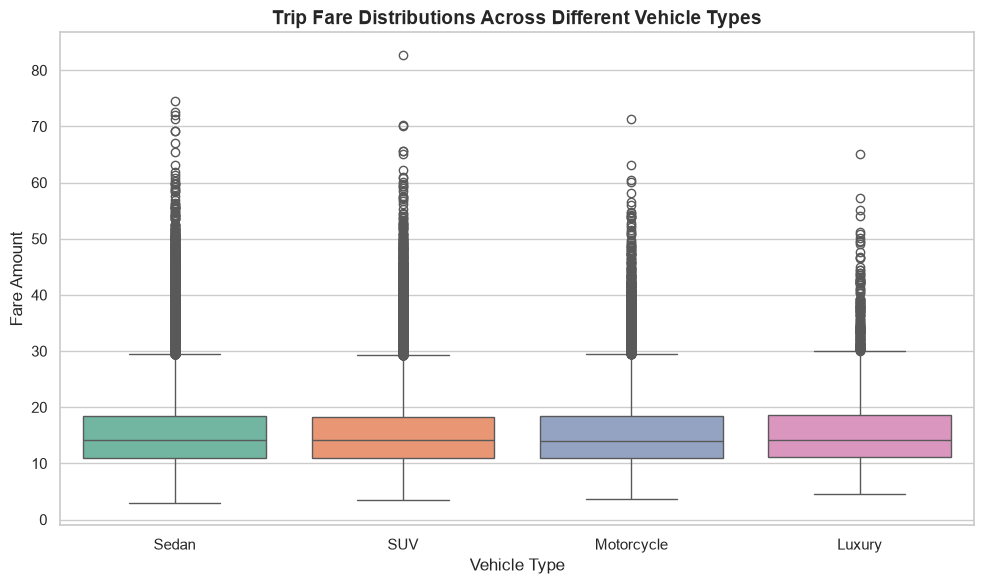

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # Enforcing correct seaborn import

# Apply a clean, modern visual theme for our data charts
sns.set_theme(style="whitegrid")

print("==========================================================")
print("ANALYSIS 1: Impact of Driver & Vehicle Metrics on Fares")
print("==========================================================")

# Step 1: Merge trips with driver metrics to connect ride experiences
# We do an inner join because we want to analyze trips that have valid driver profiles
trips_with_drivers = dfs['trips'].merge(
    dfs['drivers'][['driver_id', 'rating', 'vehicle_type', 'acceptance_rate']], 
    on='driver_id', 
    how='inner',
    suffixes=('_trip', '_driver')
)

# Step 2: Aggregate metrics by vehicle type to observe fleet behavior
vehicle_analysis = trips_with_drivers.groupby('vehicle_type').agg(
    total_trips=('trip_id', 'count'),
    avg_fare=('fare', 'mean'),
    avg_tip=('tip', 'mean'),
    avg_driver_rating=('rating', 'mean')
).reset_index()

print("\n--- Fleet Segment Performance Summary ---")
print(vehicle_analysis)

# Step 3: Visualize the spread of fares across different vehicle classes
plt.figure(figsize=(10, 6))
sns.boxplot(data=trips_with_drivers, x='vehicle_type', y='fare', palette='Set2')
plt.title('Trip Fare Distributions Across Different Vehicle Types', fontsize=14, fontweight='bold')
plt.xlabel('Vehicle Type')
plt.ylabel('Fare Amount')
plt.tight_layout()
plt.show()

##### Question 2: What is the relationship between user engagement on the app (sessions) and actual commercial conversions?

Why it matters: A classic leak in any tech funnel is the "window shopper"—users who open the app frequently, spend lots of time browsing, but don't actually book a ride (converted = 0). By identifying if certain cities or loyalty tiers have high app usage but low conversions, we can pinpoint technical bugs, high localized pricing barriers, or friction points in the app checkout flow.

ANALYSIS 2: App Engagement vs. Commercial Conversion

--- Digital Funnel Conversion Efficiency by Segment ---
       city loyalty_status  total_sessions  avg_time_on_app  \
10  Nairobi       Platinum             810       100.629630   
6     Lagos       Platinum             709        82.214386   
1     Cairo           Gold            1862       102.837809   
2     Cairo       Platinum             816        93.843137   
5     Lagos           Gold            1666        93.143457   
9   Nairobi           Gold            1669       107.362493   
4     Lagos         Bronze            9865       102.103193   
7     Lagos         Silver            4195        95.837187   
0     Cairo         Bronze           10317        98.286905   
8   Nairobi         Bronze           10116        97.350633   
3     Cairo         Silver            3972        94.262336   
11  Nairobi         Silver            4003        93.004996   

    avg_pages_visited  total_conversions  conversion_rate  
10        

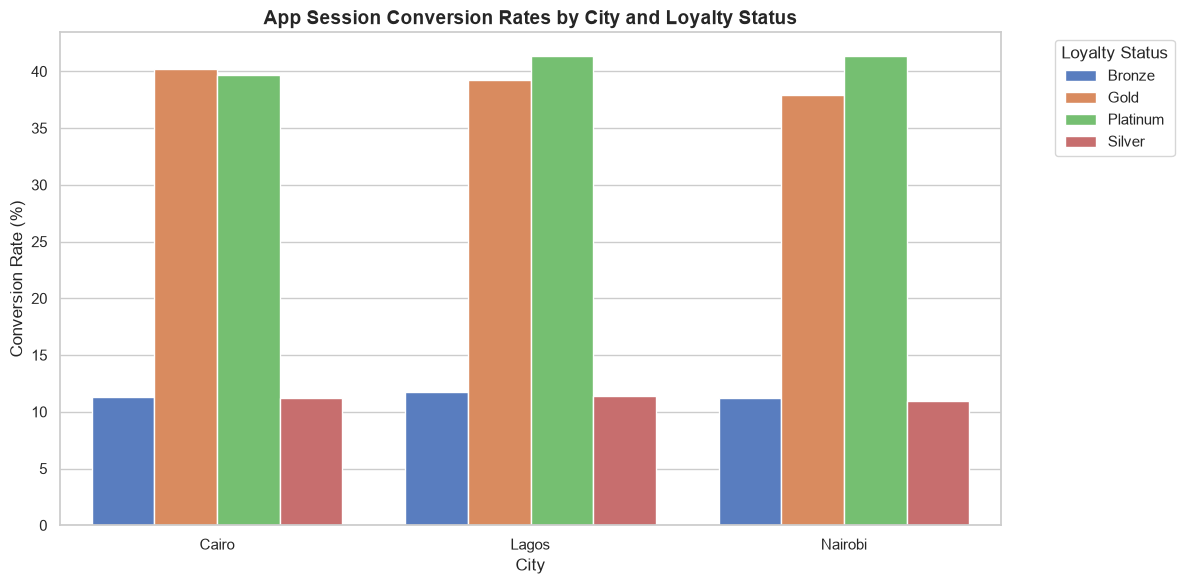

In [20]:
print("==========================================================")
print("ANALYSIS 2: App Engagement vs. Commercial Conversion")
print("==========================================================")

# Step 1: Group by city and loyalty status to see how app behavior changes by segment
engagement_funnel = dfs['sessions'].groupby(['city', 'loyalty_status']).agg(
    total_sessions=('session_id', 'count'),
    avg_time_on_app=('time_on_app', 'mean'),
    avg_pages_visited=('pages_visited', 'mean'),
    total_conversions=('converted', 'sum')
).reset_index()

# Step 2: Calculate the explicit conversion rate (Conversions / Total Sessions)
engagement_funnel['conversion_rate'] = (engagement_funnel['total_conversions'] / engagement_funnel['total_sessions']) * 100

print("\n--- Digital Funnel Conversion Efficiency by Segment ---")
print(engagement_funnel.sort_values(by='conversion_rate', ascending=False))

# Step 3: Visualize app conversion rates across cities broken down by loyalty tiers
plt.figure(figsize=(12, 6))
sns.barplot(data=engagement_funnel, x='city', y='conversion_rate', hue='loyalty_status', palette='muted')
plt.title('App Session Conversion Rates by City and Loyalty Status', fontsize=14, fontweight='bold')
plt.xlabel('City')
plt.ylabel('Conversion Rate (%)')
plt.legend(title='Loyalty Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Question 3: Do high surge pricing multipliers drive riders away, and does weather exacerbate this issue?

Why it matters: Surge pricing increases revenue per trip, but if the surge_multiplier is excessively high (e.g., 2.0x during heavy rain in Nairobi), it might cross the customer's price-tolerance threshold. This forces them to close the app and look for a competitor. By mapping surge patterns against weather conditions, we can see if our pricing algorithms are over-penalizing riders during bad weather, directly triggering churn behaviors.

ANALYSIS 3: Price Elasticity under Weather Disruptions

--- Weather and Surge Pricing Interaction Matrix ---
       city weather  completed_trips  avg_surge   avg_fare   avg_tip
6     Lagos   Rainy            13140   1.418196  19.096817  0.485950
2     Cairo   Rainy            13519   1.408137  19.030361  0.455750
10  Nairobi   Rainy            13317   1.407434  18.996851  0.479124
7     Lagos   Sunny            39691   1.083195  14.595380  0.462139
4     Lagos  Cloudy             9747   1.082559  14.594756  0.449834
5     Lagos   Foggy             3281   1.081439  14.532286  0.459336
1     Cairo   Foggy             3400   1.072500  14.557932  0.465824
3     Cairo   Sunny            40467   1.071107  14.471919  0.474063
0     Cairo  Cloudy            10050   1.070677  14.467998  0.454966
11  Nairobi   Sunny            39993   1.068805  14.426764  0.477296
8   Nairobi  Cloudy            10077   1.067788  14.362471  0.466768
9   Nairobi   Foggy             3318   1.065793  14.344717  0.4

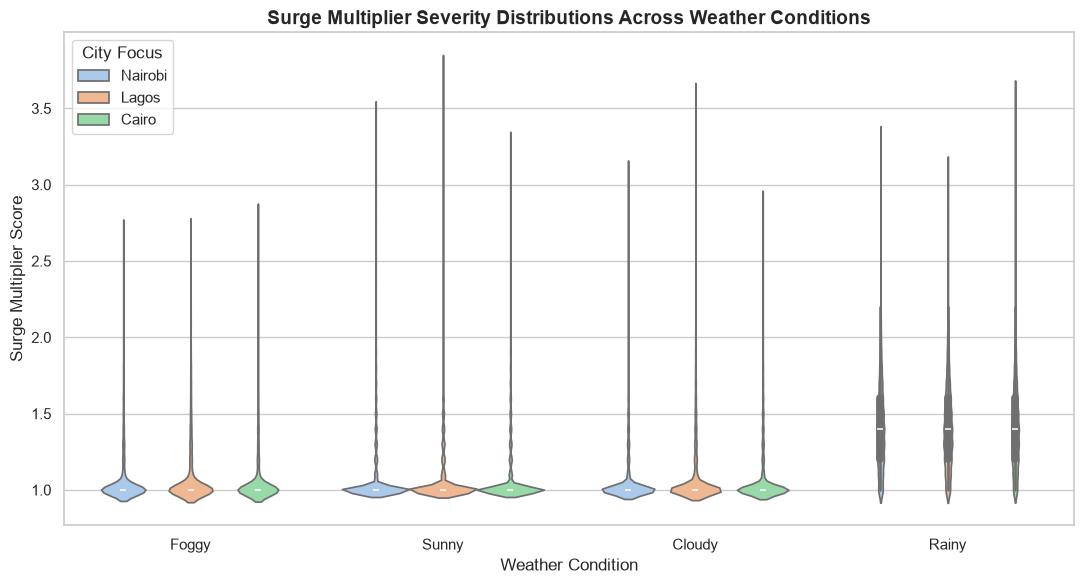

In [21]:
print("==========================================================")
print("ANALYSIS 3: Price Elasticity under Weather Disruptions")
print("==========================================================")

# Step 1: Analyze trip volume, average surge, and customer tips under different weather conditions
weather_surge_impact = dfs['trips'].groupby(['city', 'weather']).agg(
    completed_trips=('trip_id', 'count'),
    avg_surge=('surge_multiplier', 'mean'),
    avg_fare=('fare', 'mean'),
    avg_tip=('tip', 'mean')
).reset_index()

print("\n--- Weather and Surge Pricing Interaction Matrix ---")
print(weather_surge_impact.sort_values(by='avg_surge', ascending=False))

# Step 2: Create a visual cross-comparison of Surge Multipliers across weather states
plt.figure(figsize=(11, 6))
sns.violinplot(data=dfs['trips'], x='weather', y='surge_multiplier', hue='city', palette='pastel')
plt.title('Surge Multiplier Severity Distributions Across Weather Conditions', fontsize=14, fontweight='bold')
plt.xlabel('Weather Condition')
plt.ylabel('Surge Multiplier Score')
plt.legend(title='City Focus')
plt.tight_layout()
plt.show()

In [30]:
agg_sessions = dfs['sessions'].groupby('rider_id').agg(
    total_app_sessions=('session_id', 'count'),
    total_time_on_app=('time_on_app', 'sum'),
    avg_pages_visited=('pages_visited', 'mean'),
    app_conversions=('converted', 'sum')
).reset_index()

print(agg_sessions.head().to_string())

print(agg_sessions.shape)

  rider_id  total_app_sessions  total_time_on_app  avg_pages_visited  app_conversions
0   R00000                   4                368           3.000000                1
1   R00001                   3                524           2.666667                0
2   R00002                   3                573           3.000000                0
3   R00003                   3                226           1.666667                0
4   R00004                   2                 34           2.500000                0
(9929, 5)
